# Introduction

In this notebook, we are working on Simple Linear Regression, where we have a single predictor and a single target variable.

In [1]:
%cd ..
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.linear_regression import plot_perfect_linear, plot_noisy_linear

/Users/rovshanhasanov/Desktop/ML Projects/ml-from-scratch/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/rovshanhasanov/Desktop/ML Projects/ml-from-scratch


# Mathematical Background

Linear relation between two variables can be defined as:
$$
y = a*x+b
$$
where $y$ is dependent variable, $x$ is independent variable, $a$ is a scalar/slope, and $b$ is a bias term.

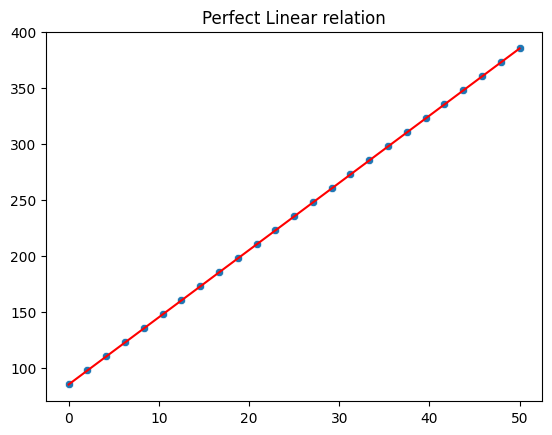

In [2]:
# Plot perfect linear relation
plot_perfect_linear(n = 25, fit_line=True)
plt.title("Perfect Linear relation")
plt.show()

The plot above visualizes a perfect linear relation between variables $x$ and $y$. Note that the red line plots the the equation and connects all $(x, y)$ pairs. If we were to find value of $y$ corresponding to, say, $x=55$, we can easily extend our line and find out where line representing $x=55$ intersects our red line.

In other words, we do not need the known pairs of $(x, y)$ to find unknown value of $y$ for an arbitrary $x$, since we know the pattern $x$ and $y$ follow, thanks to the linear equation. That is, we do not need to keep track of $x$ and $y$ value pairs to ***predict*** unseen values if we have defined the relation between them.

As one can imagine, perfect linear relation is too good to be true in real life. Even though there can be essence of linear relation between two variables, they may not render a scatterplot like above

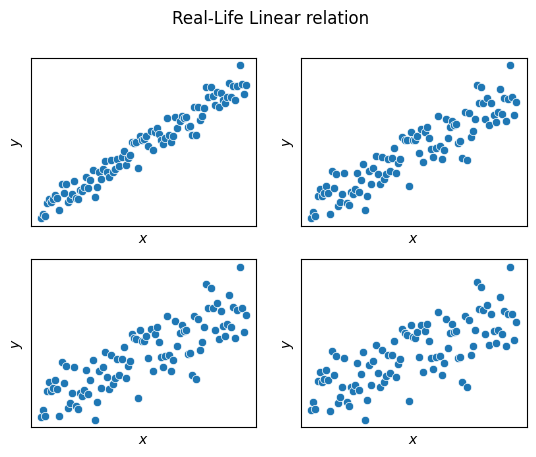

In [3]:
# Plot real-life linear relation
fig, axes = plt.subplots(2,2)
axes = axes.flatten()

for i, ax in enumerate(axes):
    plot_noisy_linear(noise_strength=(i+1)*4,ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

plt.suptitle("Real-Life Linear relation")
plt.show()

Plots above represent the linear relation we would see in real life more closely.

With these imperfect relations, can we still predict unseen values of the dependent variable?

It turns out that, although not perfectly, we can still do this if we can establish a pattern or relation between independent and dependent variables. When we looked at perfect linear relation, we defined best fitted line as the line that connects all the datapoints. How do we define best fitted line when the datapoints are clearly not on the same line?

To do this, we have to adjust/broaden the definition of the best line. Another way to frame the first scatterplot is that the distance between data points and the line is 0. Obviously, there is no single line that would produce the same number for imperfect linear relation. However, we can still find a line that minimizes that number; It would be the **closest** line to all points.



Let's revisit our formula above. We state that $y_i$ is the true value of $y$ for observation $i$. To distinguish, let's denote predicted value of the observation $\hat{y_i}$. So,

$$
\hat{y_i}=a*x_i+b
$$

$$
e_i = y_i-\hat{y_i}
$$

where $e_i$ is the error (difference between predicted and actual value).




We noted that to find the best line, we need to find such slope and bias that minimnize the sum of distances from the points to the line. Note that we cannot just minimize the sum of errors:
$$
J(a,b) = \sum_{i=1}^{m}(e_i)
$$

That's because the differences with opposite signs would cancel each other out and the results would be misleading. Technically, we can try to minimize the sum of ***absolute*** error, however, as we will see down below, using ***squared*** errors will be more convenient. So, our objective is finding such $a$ and $b$ that minimize the following:

$$
J(a,b) = \sum_{i=1}^{m}(e_i^{2})
$$


There are two methods to solve this:
<ul>
<li>Analytical Method</li>
<li>Gradient Descent</li>
</ul>

Note that the analytical method does use the gradient but it finds the slope and bias directly without the iterative loop.

## Analytical Method

From calculus, we know that a function reaches its minimum when it is derivative equals to 0. So need to find such $a$ and $b$ that makes the derivative of $J$ equal to 0.
So we need to ***partially*** differentiate $J$ for $a$ and $b$ and set it to 0 and solve it for $a$ and $b$, respectively. We will start with $b$ since it is more straightforward and will be helpful to solve the derivative equation for $a$ later on
$$
J(a,b) = \sum_{i=1}^{m}(a*x_i+b-y_i)^{2}
$$

$$
\frac{\partial J}{\partial b} = 2*\sum_{i=1}^{m}{(a*x_i+b-y_i)*1}
$$

Setting it to 0:

$$
2*\sum_{i=1}^{m}{(a*x_i+b-y_i)}=0
$$


Dividing both sides by $2$ and distributing the sum:
$$
a*\sum_{i=1}^{m}{x_i}+\sum_{i=1}^{m}{b}+\sum_{i=1}^{m}{y_i}=0
$$

Note that summing over all values of $x$ can be expressed as mean of $x$ times number of $x$. Same is true for $y$. Summing a constant $m$ times will give the constant time $m$. So:

$$
a*m*\bar{x}+m*b+m*\bar{y}=0
$$

Dividing both sides by $m$ and moving everything to the right handside except $b$:

$$
b = \bar{y} - a*\bar{x}
$$

This is an interesting observation; note that for optimal values of $a$ and $b$, the line will go through $(\bar{x}, \bar{y})$.

Let's now find derivative of $J$ with respect to $a$:

$$
\frac{\partial J}{\partial a} = \sum_{i=1}^{m}2*(a*x_i+b-y_i)*x_i
$$

Setting it to 0:

$$
2*\sum_{i=1}^{m}(a*x_i+b-y_i)*x_i=0
$$

Dividing both sides by 2 and replacing $b$ with the term we found above:

$$
\sum_{i=1}^{m}(a*x_i+\hat{y}-a*\hat{x}-y_i)*x_i=0
$$

Arranging terms inside parenthesis:

$$
\sum_{i=1}^{m}(a*(x_i-\hat{x})-(y_i - \hat{y}))*x_i=0
$$

Multipling each term inside parenthesis with $x_i$ and distributing the sum:

$$
\sum_{x=i}^{m}a*x_i*(x_i-\hat{x}) - \sum_{x=i}^{m}x_i*(y_i-\hat{y})=0
$$
